# Task 5 — Sales Prediction Using Python

## Objective

Build regression models to predict product sales based on advertising spend across three media channels: TV, Radio, and Newspaper.

## Models

- Linear Regression 
- Random Forest Regressor 

## Evaluation Metrics

- MAE
- RMSE
- R² Score

## 1. Import Libraries


In [37]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Output Folders

In [38]:
from pathlib import Path

Path("outputs/figures").mkdir(
    parents=True,
    exist_ok=True
)

## 3. Load the Dataset

The dataset is hosted in my GitHub repository and loaded directly using its raw GitHub URL. Original Source: Kaggle

In [39]:
url = "https://raw.githubusercontent.com/SiamWR/OIBSIP/refs/heads/main/DataScience-Task5-SalesPrediction/Dataset/Advertising%20Budget%20and%20Sales.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (200, 5)


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 4. Initial Dataset Inspection


In [4]:
# Inspect

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Sales ($)']

Data types:
Unnamed: 0                   int64
TV Ad Budget ($)           float64
Radio Ad Budget ($)        float64
Newspaper Ad Budget ($)    float64
Sales ($)                  float64
dtype: object


## 5. Data Cleaning

In [5]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Columns after removing the index:")
print(df.columns.tolist())

Columns after removing the index:
['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Sales ($)']


In [40]:
# Rename dataset columns

df = df.rename(columns={
    "TV Ad Budget ($)": "TV",
    "Radio Ad Budget ($)": "Radio",
    "Newspaper Ad Budget ($)": "Newspaper",
    "Sales ($)": "Sales"
})

print("Final column names:")
print(df.columns.tolist())

df.head()

Final column names:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 6. Dataset Structure


In [7]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

Dataset shape: (200, 4)

Data types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


## 7. Null Value Check

The task requires a null-value check. Missing values are checked before modeling.


In [41]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Total missing values: 0


## 8. Duplicate Check

A duplicate check is included as an additional data-quality check. Duplicate rows are not removed automatically; any treatment should be based on the observed data.


In [9]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


## 9. Descriptive Statistics


In [42]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## 10. Pairplot of All Features

The pairplot shows the distributions and pairwise relationships among TV, Radio, Newspaper, and Sales.


C:\Users\88019\anaconda3\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\88019\AppData\Local\Temp\ipykernel_26456\1553967806.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


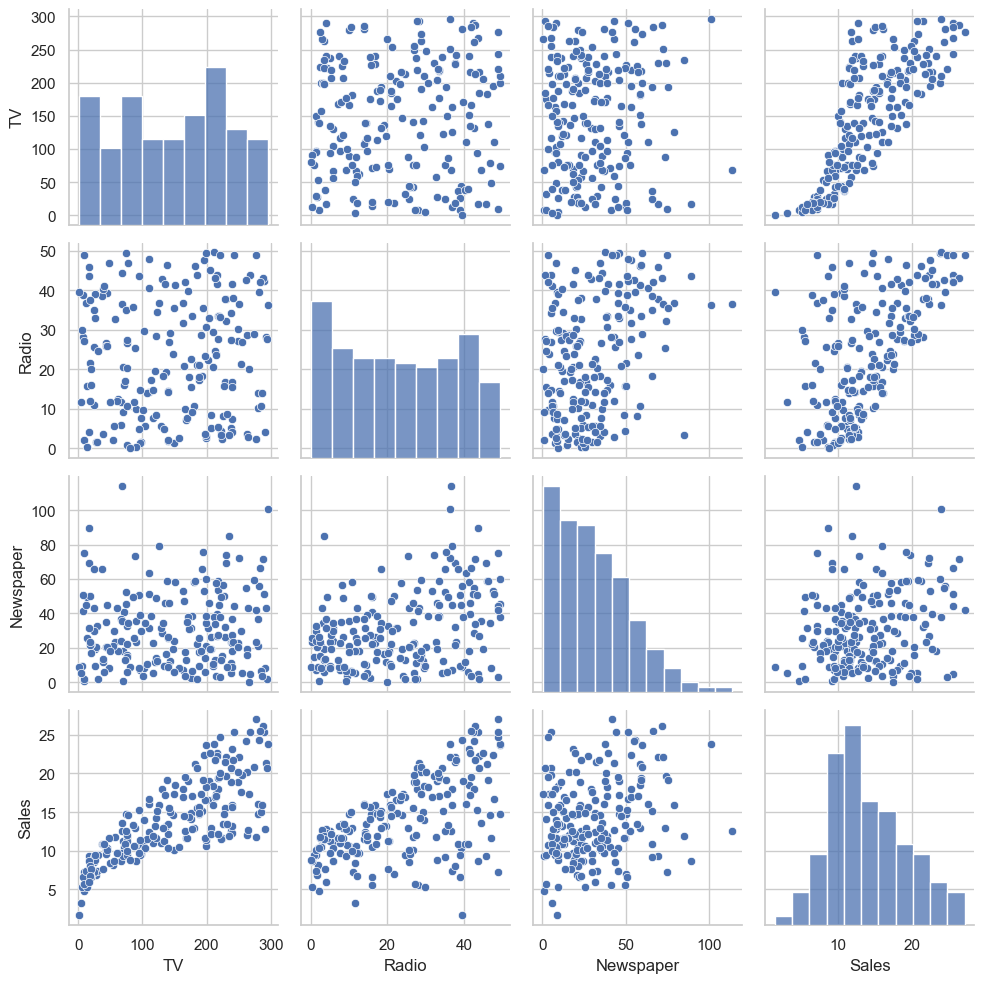

In [11]:
# Pairplot of all features

sns.pairplot(df)

plt.tight_layout()

plt.savefig(
    "outputs/figures/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Sales vs TV Advertising Spend


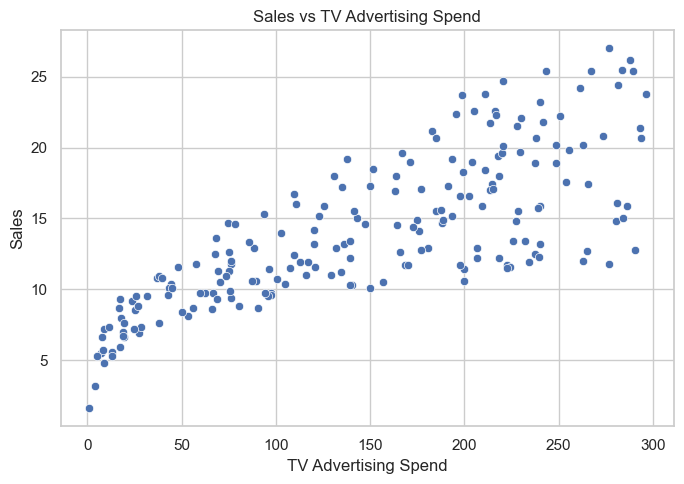

In [12]:
# Scatter plot: Sales vs TV advertising spend

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("Sales vs TV Advertising Spend")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    "outputs/figures/sales_vs_tv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Sales vs Radio Advertising Spend


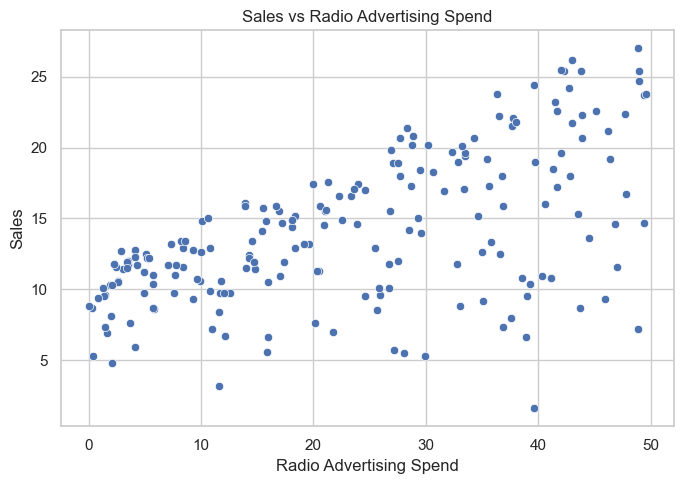

In [13]:
# Scatter plot: Sales vs Radio advertising spend

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales"
)

plt.title("Sales vs Radio Advertising Spend")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    "outputs/figures/sales_vs_radio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. Sales vs Newspaper Advertising Spend


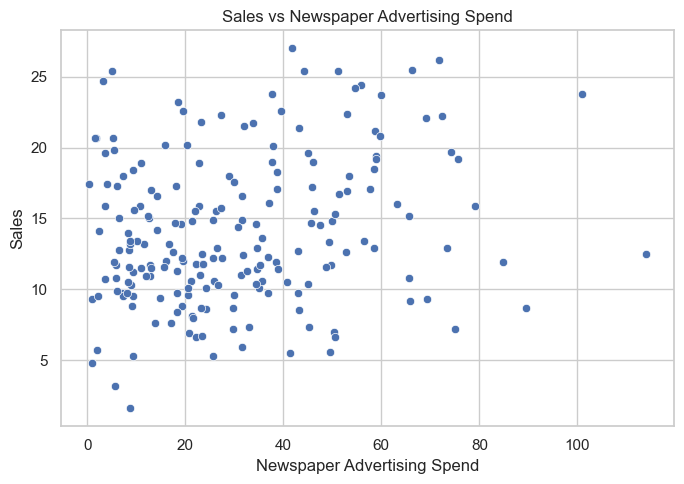

In [14]:
# Scatter plot: Sales vs Newspaper advertising spend

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales"
)

plt.title("Sales vs Newspaper Advertising Spend")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    "outputs/figures/sales_vs_newspaper.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Correlation Matrix Heatmap

The correlation matrix measures linear association between the numerical variables. Correlation does not establish causal impact.


In [15]:
# Calculate the correlation matrix

correlation_matrix = df.corr()

correlation_matrix

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


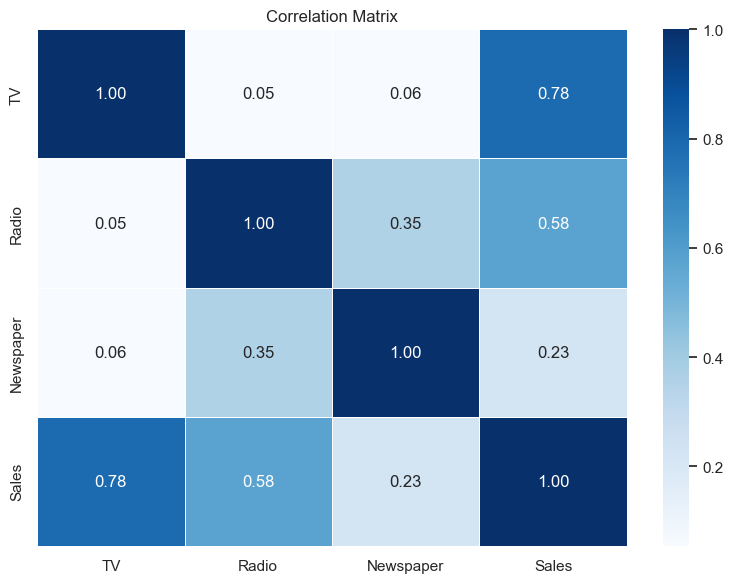

In [16]:
# Visualize the correlation matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "outputs/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Define Features and Target

The three advertising channels are the predictors and Sales is the target:

**TV + Radio + Newspaper → Sales**


In [17]:
# Define predictor variables and target variable

X = df[[
    "TV",
    "Radio",
    "Newspaper"
]]

y = df["Sales"]

print("Feature columns:", X.columns.tolist())
print("Target:", y.name)

Feature columns: ['TV', 'Radio', 'Newspaper']
Target: Sales


## 16. Train/Test Split

The data are split into training and testing sets. A fixed random state is used to make the experiment reproducible.


In [18]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


## 17. Linear Regression — Baseline Model

Linear Regression is the required baseline model. It assumes a linear relationship between the predictors and the target.


In [19]:
# Initialize and train the Linear Regression baseline

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


## 18. Linear Regression Predictions


In [20]:
# Generate predictions using Linear Regression

linear_predictions = linear_model.predict(X_test)

linear_predictions[:10]

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967])

## 19. Linear Regression Coefficients

The coefficients describe the expected change in predicted Sales for a one-unit change in each advertising variable while holding the other predictors constant.


In [21]:
# Inspect Linear Regression coefficients

linear_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

linear_coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [22]:
# Display the Linear Regression intercept

print("Linear Regression intercept:", linear_model.intercept_)

Linear Regression intercept: 2.9790673381226256


## 20. Random Forest Regressor — Additional Model

Random Forest Regressor is used as the required additional regression model. It can capture nonlinear relationships and interactions that a linear model may not capture.


In [23]:
# Initialize and train the Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


## 21. Random Forest Predictions


In [24]:
# Generate predictions using Random Forest

rf_predictions = rf_model.predict(X_test)

rf_predictions[:10]

array([17.7615, 21.6665, 20.6595,  6.7395, 23.096 , 13.5155, 22.486 ,
        9.6625, 11.8545, 15.504 ])

## 22. Evaluation Metrics

**MAE (Mean Absolute Error):** average absolute prediction error. Lower is better.

**RMSE (Root Mean Squared Error):** measures prediction error while giving greater weight to larger errors. Lower is better.

**R² Score:** measures the proportion of target variance explained by the model. Higher is better.


In [25]:
# Function for evaluating regression models

def evaluate_regression_model(y_true, predictions):
    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    return mae, rmse, r2

## 23. Evaluate Both Models

Both models are evaluated on the same held-out test set using MAE, RMSE, and R².


In [26]:
# Evaluate Linear Regression

linear_mae, linear_rmse, linear_r2 = evaluate_regression_model(
    y_test,
    linear_predictions
)

# Evaluate Random Forest

rf_mae, rf_rmse, rf_r2 = evaluate_regression_model(
    y_test,
    rf_predictions
)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

print("\nRandom Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Linear Regression
MAE : 1.4607567168117606
RMSE: 1.7815996615334502
R²  : 0.899438024100912

Random Forest
MAE : 0.6287125000000021
RMSE: 0.7572349907723515
R²  : 0.9818333477552758


## 24. Model Comparison


In [27]:
# Create a model comparison table

results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R²": [
        linear_r2,
        rf_r2
    ]
})

results_df

,Model,MAE,RMSE,R²
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.628713,0.757235,0.981833


In [28]:
# Save model comparison results

results_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

## 25. Best Model Selection

The model with the highest R² score is selected as the best-performing model. MAE and RMSE are also considered when interpreting overall performance.


In [29]:
# Select the best-performing model using the highest R² score

best_model_name = results_df.loc[
    results_df["R²"].idxmax(),
    "Model"
]

print("Best-performing model:", best_model_name)

Best-performing model: Random Forest


In [30]:
# Select predictions corresponding to the best model

if best_model_name == "Linear Regression":
    best_predictions = linear_predictions
else:
    best_predictions = rf_predictions

print("Predictions selected for:", best_model_name)

Predictions selected for: Random Forest


## 26. Residual Analysis

Residuals are the differences between actual and predicted Sales. The residual plot is used to examine whether prediction errors appear randomly distributed around zero or show a systematic pattern.


In [31]:
# Calculate residuals for the best-performing model

residuals = y_test - best_predictions

print("First 10 residuals:")
print(residuals.head(10))

First 10 residuals:
95    -0.8615
15     0.7335
30     0.7405
158    0.5605
128    1.6040
115   -0.9155
69    -0.1860
170   -1.2625
174   -0.3545
45    -0.6040
Name: Sales, dtype: float64


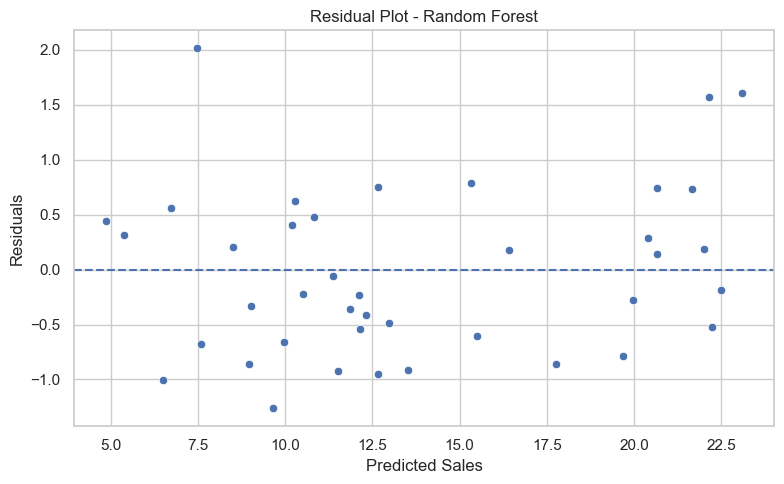

In [32]:
# Residual plot for the best-performing model

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    f"Residual Plot - {best_model_name}"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.tight_layout()

plt.savefig(
    "outputs/figures/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Residual Interpretation

The residuals are generally scattered around zero without a strong systematic pattern, suggesting that the Random Forest model captures the main relationship between advertising spend and sales reasonably well.


## 27. Advertising Channel Feature Importance

Random Forest provides feature importance values that can be used to compare the relative predictive contribution of TV, Radio, and Newspaper within the trained model.


In [33]:
# Calculate Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624727
1,Radio,0.362119
2,Newspaper,0.013153


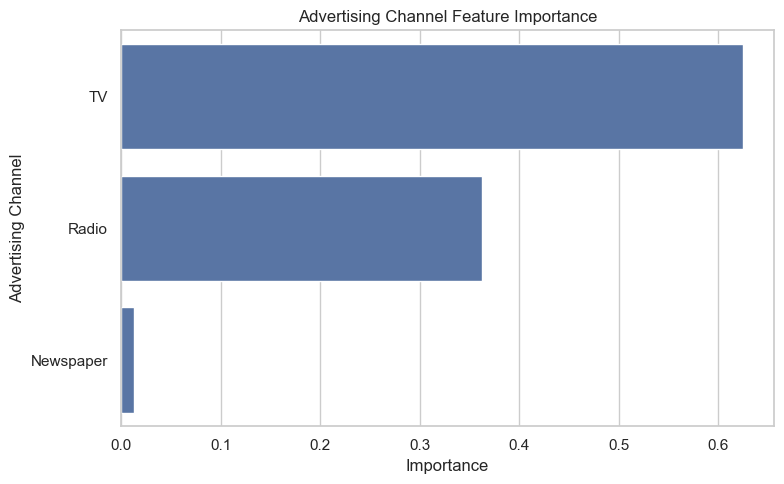

In [34]:
# Visualize advertising channel feature importance

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Advertising Channel Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.tight_layout()

plt.savefig(
    "outputs/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# Identify the advertising channel with the highest predictive importance

most_important_channel = feature_importance.iloc[0]["Feature"]
highest_importance = feature_importance.iloc[0]["Importance"]

print(
    f"Highest predictive importance: {most_important_channel}"
)

print(
    f"Importance: {highest_importance:.4f}"
)

Highest predictive importance: TV
Importance: 0.6247


### Interpretation

TV has the highest predictive importance (0.6247) among the three advertising channels, followed by Radio and Newspaper. This reflects predictive importance in the Random Forest model, not causal impact.

## 28. Final Model Summary


In [36]:
# Display the final model comparison and key findings

print("Final Model Comparison")
print("=" * 50)

display(results_df.round(4))

print("\nBest-performing model:", best_model_name)
print(
    "Highest predictive-importance channel:",
    most_important_channel
)

Final Model Comparison


,Model,MAE,RMSE,R²
0,Linear Regression,1.4608,1.7816,0.8994
1,Random Forest,0.6287,0.7572,0.9818



Best-performing model: Random Forest
Highest predictive-importance channel: TV


## Conclusion

This project developed regression models to predict sales from TV, Radio, and Newspaper advertising spend. Random Forest outperformed the Linear Regression baseline, achieving an **R² of 0.9818**, **MAE of 0.6287**, and **RMSE of 0.7572**.

Feature importance identified **TV advertising as the most predictive channel**, followed by Radio and Newspaper. The residuals were generally scattered around zero without a strong systematic pattern, indicating that the Random Forest model captured the main relationship between advertising spend and sales reasonably well.

## 30. References

1. Kaggle — Advertising Sales Dataset.
2. scikit-learn Documentation — LinearRegression.
3. scikit-learn Documentation — RandomForestRegressor.
4. scikit-learn Documentation — Regression Model Evaluation Metrics.
